# **CD20+, CD21+, CD21+CD23+ Domain Analysis**


## Environment Setup and Imports

In [2]:
# Load necessary libraries
import sys
import os
import anndata as ad
import pandas as pd
import pathlib
import scanpy as sc
import numpy as np
import seaborn as sns; sns.set(color_codes=True)
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import pearson3
# Import Scimap
import scimap as sm
#import rpy2

from colorcet.plotting import swatch, swatches, candy_buttons

# import holoviews as hv
# hv.extension('bokeh')
# import scimap
import scimap as sm 

C:\Users\emo963\AppData\Local\anaconda3\envs\scimap\lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.3 when it was built against 1.14.2, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


Running SCIMAP  2.0.5


C:\Users\emo963\AppData\Local\anaconda3\envs\scimap\lib\site-packages\tqdm\auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



In [3]:
#FOR USE WITH DESKTOP
os.chdir ("C:/Users/emo963/HMS Dropbox/Emmanuel Ogbonna/_Emmanuel_Ogbonna’s files/HARVARD STUFF/_research/_TB background and analysis/Tuberculosis/Emmanuel TB CyCIF docs/EO7_B5_3D_IMAGE RECONSTRUCTION/")

## Data Loading and Input Configuration

In [4]:
adata = ad.read("EO7_B4_3D_phenotyped_NO_cylinter.h5ad")

In [5]:
adata

AnnData object with n_obs × n_vars = 46548787 × 23
    obs: 'X_centroid', 'Y_centroid', 'Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'Solidity', 'Extent', 'Orientation', 'phenotype', 'Z_centroid', 'TLS_num', 'CellID', 'imageid', 'TLS_ROI', 'QC', 'Ki-67+ cells', 'Z_centroid_0_indexing', 'phenotype_prolif', 'CD21+ cells', 'CD21+ CD23+ cells', 'TIC_num', 'Ki-67+ CD21+ CD23+ cells', 'phenotype_CD21_CD23_Ki67', 'CD21_CD23_merge', 'TLS_domain', 'CD20_domain_old', 'CD20_domain', 'CD21_domain_old', 'CD21_domain', 'CD23_domain_old', 'CD23_domain', 'TLS_domain_old', 'CD21_CD23_merge_old', 'TLS_domain_seg', 'phenotype_TIGIT+', 'phenotype_Tfh', 'spatial_lda_knn10', 'gran_ROI'
    uns: 'all_markers', 'dendrogram_spatial_lda_knn10', 'gates', 'spatial_lda'
    obsm: 'spatial'
    layers: 'log'

In [27]:
#TLSs with 75% QC
TLS_QC75 = [    17, 29, 80, 105, 109, 122, 131, 135, 142, 144, 145, 146, 148, 149, 153, 154, 157, 158, 162, 163, 165, 167,    171, 178, 181, 182, 183, 184, 186, 187, 190, 191, 193, 195, 197, 200, 203, 204, 205, 206, 207, 208, 210,
    211, 213, 216, 217, 218, 219, 222, 223, 224, 225, 226, 229, 230, 231, 232, 233, 235, 236, 237, 238, 240,    241, 242, 243, 244, 246, 247, 248, 249, 250, 251, 252, 253, 254, 256, 257, 258, 259, 260, 261, 263, 264,    269, 270, 272, 274, 276, 278, 280, 282, 286, 287, 288, 289, 290, 291, 292, 293, 294, 295, 299, 300, 302,    303, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314, 319, 320, 321, 322, 323, 324, 325, 326, 327, 329,
    330, 331, 332, 333, 334, 335, 336, 337, 338, 341, 343, 344, 345, 346, 347, 349, 352, 355, 356, 357, 359,    360, 361, 362, 363, 365, 366, 367, 368, 369, 370, 371, 372, 373, 374, 375, 376, 377, 378, 379, 380, 381,    382, 383, 384, 385, 386, 387, 388, 389, 390, 391, 392, 393, 394, 395, 396, 397, 398, 399, 400, 401, 402,    403, 405, 406, 407, 408, 409, 410, 412, 414, 415, 416, 417, 418, 419, 420, 422, 423, 424, 425, 426, 427,
    428, 429, 430, 431, 432, 433, 434, 435, 436, 438, 439, 440, 441, 442, 443, 444, 445, 447, 448, 449, 451,    452, 453, 454, 455, 457, 458, 459, 460, 461, 462, 463, 464, 465, 466, 467, 468, 469, 470, 471, 472, 473,    475, 476, 477, 478, 479, 480, 481, 482, 483, 486, 487, 488, 489, 490, 491, 492, 493, 497, 498, 500, 501,    502, 504, 505, 507, 508, 509, 510, 511, 514, 515, 517, 518, 521, 522, 523, 524, 525, 526, 527, 528, 529,
    530, 531, 532, 533, 534, 536, 538, 539, 540, 543, 545, 547, 548, 549, 551, 553, 554, 555, 556, 558, 559,    561, 562, 563, 564, 565, 566, 567, 568, 571, 572, 574, 582, 583, 584, 585, 587, 588, 590, 591, 592, 593,    594, 595, 596, 597, 599, 602, 603, 604, 605, 607, 609, 613, 618, 619, 620, 621, 622, 624, 625, 626, 627,    631, 632, 636, 637, 639, 640, 641, 642, 643, 645, 646, 647, 648, 649, 655, 657, 658, 659, 660, 663, 664,
    665, 667, 668, 670, 672, 673, 674, 677, 678, 679, 688, 689, 690, 691, 693, 695, 697, 698, 700, 701, 702,    703, 704, 705, 706, 708, 709, 711, 713, 715, 720, 721, 722, 724, 728, 731, 735, 739, 740, 741, 743, 744,    746, 749, 757, 758, 760, 764, 765, 766, 767, 770, 772, 774, 776, 777, 778, 779, 780, 781, 782, 783, 788,    789, 792, 796, 800, 804, 807, 808, 810, 815, 816, 818, 822, 823, 830, 836, 842, 844, 852, 859, 860, 864,
    878, 880, 881, 887, 890, 901, 916]


In [10]:
# Define the categories with their corresponding numeric values
Early = [149, 190, 206, 244, 254, 256, 263, 272, 282, 295, 299, 303, 319, 326, 345, 362, 375, 376, 377, 378,          396, 398, 402, 417, 420, 439, 468, 469, 470, 472, 480, 492, 493, 500, 501, 522, 530, 532, 539, 548,         559, 571, 594, 596, 597, 618, 619, 620, 621, 624, 632, 637, 649, 659, 665, 667, 690, 691, 720, 731,         741, 749, 766, 772, 778, 780, 788, 852, 878, 901]

Primary = [135, 142, 145, 153, 162, 167, 178, 191, 193, 195, 226, 229, 240, 242, 243, 253, 292, 305, 309, 312,           321, 359, 361, 370, 374, 386, 395, 406, 408, 415, 423, 426, 429, 430, 431, 440, 448, 451, 460, 475,            497, 504, 514, 526, 534, 556, 561, 563, 566, 583, 591, 664, 672, 688, 698, 713, 722, 744, 757, 758,           760, 764, 774, 781, 792, 796, 808, 810, 815, 818, 836, 844, 860, 864, 880, 887, 916]

Secondary =  [17, 29, 80, 105, 109, 122, 131, 144, 146, 148, 154, 157, 158, 163, 165, 171, 181, 182, 183, 184,             186, 187, 197, 200, 203, 204, 205, 207, 208, 210, 211, 213, 216, 217, 218, 219, 222, 223, 224, 225,             230, 231, 232, 233, 235, 236, 237, 238, 241, 246, 247, 248, 249, 250, 251, 252, 257, 258, 259, 260,             261, 264, 269, 270, 274, 276, 278, 280, 286, 287, 288, 289, 290, 291, 293, 294, 300, 302, 306, 307,             308, 310, 311, 313, 314, 320, 322, 323, 324, 325, 327, 329, 330, 331, 332, 333, 334, 335, 336, 337,             338, 341, 343, 344, 346, 347, 349, 352, 355, 356, 357, 360, 363, 365, 366, 367, 368, 369, 371, 372,             373, 379, 380, 381, 382, 383, 384, 385, 387, 388, 389, 390, 391, 392, 393, 394, 397, 399, 400, 401,             403, 405, 407, 409, 410, 412, 414, 416, 418, 419, 422, 424, 425, 427, 428, 432, 433, 434, 435, 436,             438, 441, 442, 443, 444, 445, 447, 449, 452, 453, 454, 455, 457, 458, 459, 461, 462, 463, 464, 465,             466, 467, 471, 473, 476, 477, 478, 479, 481, 482, 483, 486, 487, 488, 489, 490, 491, 498, 502, 505,             507, 508, 509, 510, 511, 515, 517, 518, 521, 523, 524, 525, 527, 528, 529, 531, 533, 536, 538, 540,             543, 545, 547, 549, 551, 553, 554, 555, 558, 562, 564, 565, 567, 568, 572, 574, 582, 584, 585, 587,             588, 590, 592, 593, 595, 599, 602, 603, 604, 605, 607, 609, 613, 622, 625, 626, 627, 631, 636, 639,             640, 641, 642, 643, 645, 646, 647, 648, 655, 657, 658, 660, 663, 668, 670, 673, 674, 677, 678, 679,             689, 693, 695, 697, 700, 701, 702, 703, 704, 705, 706, 708, 709, 711, 715, 721, 724, 728, 735, 739,             740, 743, 746, 765, 767, 770, 776, 777, 779, 782, 783, 789, 800, 804, 807, 816, 822, 823, 830, 842,             859, 881, 890]


## CD20, CD21, and CD23 Domain Segmentation

In [56]:
#### SEGMENT CD20, CD21 AND CD21+CD23+ REGIONS USING KNN ANALYSIS

import pandas as pd
import numpy as np
import networkx as nx
from sklearn.neighbors import kneighbors_graph
import matplotlib.pyplot as plt
import os

# ───────────────────────────────────────────────

# ───────────────────────────────────────────────
# KNN CONNECTED COMPONENTS (ACTIVE)
# ───────────────────────────────────────────────
def knn_connected_components(df, k=10, voxel_size=(0.325, 0.325, 15.0)):
    """KNN graph + connected components in 3D (anisotropy-aware)."""
    if df.empty:
        return 0, {}

    coords = df[["X_centroid", "Y_centroid", "Z_centroid"]].values.astype(float)

    # Rescale by voxel size → isotropic distances
    coords[:, 0] /= voxel_size[0]
    coords[:, 1] /= voxel_size[1]
    coords[:, 2] /= voxel_size[2]

    if coords.shape[0] < 2:
        return 0, {}

    k_eff = min(k, coords.shape[0] - 1)

    A = kneighbors_graph(coords, n_neighbors=k_eff, include_self=False)
    G = nx.from_scipy_sparse_array(A)

    components = list(nx.connected_components(G))

    domain_map = {}
    for comp_id, comp_nodes in enumerate(components, start=1):
        for node in comp_nodes:
            domain_map[df.index[node]] = comp_id

    return len(components), domain_map

# ───────────────────────────────────────────────
# TLS DOMAIN BUILDER — KNN ONLY
# ───────────────────────────────────────────────
def build_tls_domains_dual(adata, Early, Primary, Secondary,
                           voxel_size=(0.325, 0.325, 15.0), k=10):

    # Create output columns
    for marker in ["CD20", "CD21", "CD23"]:

        # KNN domains (active)
        adata.obs[f"{marker}_domain_knn_new"] = pd.Series([None] * adata.n_obs, dtype="object")

    results_knn = []

    # Process TLS one-by-one
    for tls_id, tls_df in adata.obs.groupby("TLS_num"):

        if tls_id in Early:
            tls_type = "Early"
        elif tls_id in Primary:
            tls_type = "Primary"
        elif tls_id in Secondary:
            tls_type = "Secondary"
        else:
            continue

        # -------------------------
        # CD20 domains (KNN only)
        # -------------------------
        cd20_df = tls_df[tls_df["phenotype"] == "B cell"]

        n_cd20_k, map_k = knn_connected_components(cd20_df, k, voxel_size)
        for idx, dom in map_k.items():
            adata.obs.loc[idx, "CD20_domain_knn_new"] = f"TLS{tls_id}_CD20_{dom}"
            
        # Initialize counters
        n_cd21_k = n_cd23_k = 0

        # -------------------------
        # CD21 domains
        # -------------------------
        if tls_type in ["Primary", "Secondary"] and "CD21+ cells" in tls_df.columns:
            cd21_df = tls_df[tls_df["CD21+ cells"] == "CD21+ cells"]   # ← FIXED

            n_cd21_k, map_k = knn_connected_components(cd21_df, k, voxel_size)
            for idx, dom in map_k.items():
                adata.obs.loc[idx, "CD21_domain_knn_new"] = f"TLS{tls_id}_CD21_{dom}"

        # -------------------------
        # CD23 domains
        # -------------------------
        if tls_type == "Secondary" and "CD21+ CD23+ cells" in tls_df.columns:
            cd23_df = tls_df[tls_df["CD21+ CD23+ cells"] == "CD21+ CD23+ cells"]  # ← FIXED

            n_cd23_k, map_k = knn_connected_components(cd23_df, k, voxel_size)
            for idx, dom in map_k.items():
                adata.obs.loc[idx, "CD23_domain_knn_new"] = f"TLS{tls_id}_CD23_{dom}"


        # Store summary
        results_knn.append({
            "TLS_num": tls_id,
            "TLS_type": tls_type,
            "n_CD20_domains": n_cd20_k,
            "n_CD21_domains": n_cd21_k,
            "n_CD23_domains": n_cd23_k,
            "multiple_CD21": n_cd21_k > 1,
            "multiple_CD23": n_cd23_k > 1
        })

    # RETURN KNN ONLY
    return pd.DataFrame(results_knn), adata

# ───────────────────────────────────────────────
# PNG EXPORT (DEFAULTS TO KNN)
# ───────────────────────────────────────────────
def export_tls_slices(adata, tls_id, method="knn", outdir="tls_pngs"):
    os.makedirs(outdir, exist_ok=True)

    cd20_col = f"CD20_domain_id_{method}"
    cd21_col = f"CD21_domain_id_{method}"
    cd23_col = f"CD23_domain_id_{method}"

    tls_df = adata.obs[adata.obs["TLS_num"] == tls_id]
    if tls_df.empty:
        print(f"No data for TLS {tls_id}")
        return

    for z in sorted(tls_df["Z_centroid"].unique()):
        slice_df = tls_df[tls_df["Z_centroid"] == z]

        plt.figure(figsize=(6, 6))
        plt.scatter(slice_df["X_centroid"], slice_df["Y_centroid"],
                    c=pd.factorize(slice_df[cd20_col])[0],
                    cmap="tab20", s=5, alpha=0.8, label="CD20")

        if slice_df[cd21_col].notna().any():
            plt.scatter(slice_df["X_centroid"], slice_df["Y_centroid"],
                        c=pd.factorize(slice_df[cd21_col])[0],
                        cmap="Set1", s=10, alpha=0.6, marker="x", label="CD21")

        if slice_df[cd23_col].notna().any():
            plt.scatter(slice_df["X_centroid"], slice_df["Y_centroid"],
                        c=pd.factorize(slice_df[cd23_col])[0],
                        cmap="Dark2", s=15, alpha=0.6, marker="^", label="CD23")

        plt.title(f"TLS {tls_id} – Z={z} ({method})")
        plt.xlabel("X (µm)")
        plt.ylabel("Y (µm)")
        plt.legend(markerscale=3, fontsize=8)

        fname = os.path.join(outdir, f"TLS{tls_id}_Z{z}_{method}.png")
        plt.savefig(fname, dpi=200, bbox_inches="tight")
        plt.close()

### Domain Merging and Final Construction

In [177]:
import pandas as pd

def merge_cd21_cd23_domains(adata):
    """
    Create a merged CD21/CD23 domain column.
    Rules:
      - If CD23 domain overlaps CD21 → merge into 'CD21ID_CD23ID'
      - If CD21 has no CD23 overlap → keep CD21 only
      - CD23-only (no CD21 overlap) → dropped
    """

    cd21_col = "CD21_domain"
    cd23_col = "CD23_domain"
    merged_col = "CD21_CD23_merge"

    adata.obs[merged_col] = None

    for tls_id, tls_df in adata.obs.groupby("TLS_num"):
        for cd21_dom, dom_df in tls_df.groupby(cd21_col):
            if pd.isna(cd21_dom):  # skip NAs
                continue

            # find CD23 domains overlapping with this CD21
            cd23_overlap = dom_df[cd23_col].dropna().unique()

            if len(cd23_overlap) == 0:
                # No CD23 → CD21 only
                mask = tls_df[cd21_col] == cd21_dom
                adata.obs.loc[mask.index[mask], merged_col] = cd21_dom
            else:
                # Merge all overlaps
                for cd23_dom in cd23_overlap:
                    mask = (tls_df[cd21_col] == cd21_dom) & (tls_df[cd23_col] == cd23_dom)
                    merged_label = f"{cd21_dom}_{cd23_dom}"
                    adata.obs.loc[mask.index[mask], merged_col] = merged_label

                # Also keep CD21-only cells from same domain
                mask_cd21_only = (tls_df[cd21_col] == cd21_dom) & (tls_df[cd23_col].isna())
                adata.obs.loc[mask_cd21_only.index[mask_cd21_only], merged_col] = cd21_dom

    return adata

# Run
adata = merge_cd21_cd23_domains(adata)

# Quick check: count merged vs CD21-only
adata.obs["CD21_CD23_merge"].value_counts()

C:\Users\emo963\AppData\Local\Temp\ipykernel_42600\2358337346.py:19: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\emo963\AppData\Local\Temp\ipykernel_42600\2358337346.py:19: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\emo963\AppData\Local\Temp\ipykernel_42600\2358337346.py:19: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

C:\Users\emo963\AppData\Local\Temp\ipykernel_42600\2358337346.py:19: FutureWarn

CD21_CD23_merge
TLS154_CD21_3                  9208
TLS434_CD21_1                  8170
TLS640_CD21_1                  7541
TLS355_CD21_1                  6484
TLS445_CD21_1                  6469
                               ... 
TLS154_CD21_1_TLS154_CD23_3       1
TLS154_CD21_2_TLS154_CD23_2       1
TLS260_CD21_1_TLS260_CD23_2       1
TLS782_CD21_2_TLS782_CD23_2       1
TLS274_CD21_2_TLS274_CD23_2       1
Name: count, Length: 939, dtype: int64

In [178]:
import pandas as pd

# --- Helper to assign class ---
def get_class(tls):
    if tls in Early:
        return "Early"
    elif tls in Primary:
        return "Primary"
    elif tls in Secondary:
        return "Secondary"
    else:
        return "Unclassified"

# --- Summarize ---
cd20_col = "CD20_domain"
cd21_col = "CD21_domain"
cd23_col = "CD23_domain"
cd21_23_col = "CD21_CD23_merge"

summary = (
    adata.obs.groupby("TLS_num")
    .agg({
        cd20_col: lambda x: sorted([d for d in x.dropna().unique() if pd.notna(d)]),
        cd21_col: lambda x: sorted([d for d in x.dropna().unique() if pd.notna(d)]),
        cd23_col: lambda x: sorted([d for d in x.dropna().unique() if pd.notna(d)]),
        cd21_23_col: lambda x: sorted([d for d in x.dropna().unique() if pd.notna(d)]),
    })
    .reset_index()
)

# Add class + counts
summary["Class"] = summary["TLS_num"].apply(get_class)
summary["n_cd20_domains"] = summary[cd20_col].apply(len)
summary["n_cd21_domains"] = summary[cd21_col].apply(len)
summary["n_cd23_domains"] = summary[cd23_col].apply(len)
summary["n_CD21_CD23_merge"] = summary[cd21_23_col].apply(len)

# Reorder columns
summary = summary[
    ["TLS_num", "Class", cd20_col, "n_cd20_domains",
     cd21_col, "n_cd21_domains",
     cd23_col, "n_cd23_domains",
     cd21_23_col, "n_CD21_CD23_merge"]
]

# Save
summary.to_csv("TLS_domain_summary.csv", index=False)

print("✅ Saved TLS_domain_summary.csv")
summary.head(10)
# Save
summary.to_csv("TLS_domain_summary.csv", index=False)

print("✅ Saved TLS_domain_summary.csv")
summary.head(10)

✅ Saved TLS_domain_summary.csv
✅ Saved TLS_domain_summary.csv


,TLS_num,Class,CD20_domain,n_cd20_domains,CD21_domain,n_cd21_domains,CD23_domain,n_cd23_domains,CD21_CD23_merge,n_CD21_CD23_merge
0,0,Unclassified,[],0,[],0,[],0,[],0
1,1,Unclassified,[],0,[],0,[],0,[],0
2,2,Unclassified,[],0,[],0,[],0,[],0
3,3,Unclassified,[],0,[],0,[],0,[],0
4,4,Unclassified,[],0,[],0,[],0,[],0
5,5,Unclassified,[],0,[],0,[],0,[],0
6,6,Unclassified,[],0,[],0,[],0,[],0
7,7,Unclassified,[],0,[],0,[],0,[],0
8,8,Unclassified,[],0,[],0,[],0,[],0
9,9,Unclassified,[],0,[],0,[],0,[],0


In [179]:
import pandas as pd
import numpy as np

def build_concentric_domains(adata,
                             col_cd20="CD20_domain",
                             col_cd21="CD21_domain",
                             col_cd23="CD23_domain",
                             col_merge="CD21_CD23_merge"):
    # normalize NA-like strings
    for c in [col_cd20, col_cd21, col_cd23, col_merge]:
        if c in adata.obs:
            adata.obs[c] = (adata.obs[c]
                            .astype("string")
                            .replace({"<NA>": pd.NA, "nan": pd.NA, "None": pd.NA}))
        else:
            adata.obs[c] = pd.NA  # ensure column exists

    cd20 = adata.obs[col_cd20]
    cd21 = adata.obs[col_cd21]
    cd23 = adata.obs[col_cd23]
    merge = adata.obs[col_merge]

    concentric = pd.Series("Other", index=adata.obs.index, dtype="string")

    # 1) CD21+CD23+ ring: prefer precomputed merge; if missing, fallback to CD21+"_"+CD23
    mask_both = cd21.notna() & cd23.notna()
    concentric.loc[mask_both & merge.notna()] = merge[mask_both & merge.notna()]
    concentric.loc[mask_both & merge.isna()] = (cd21[mask_both & merge.isna()] + "_" +
                                                cd23[mask_both & merge.isna()])

    # 2) CD21-only ring (no CD23)
    mask_cd21_only = cd21.notna() & cd23.isna()
    concentric.loc[mask_cd21_only] = cd21[mask_cd21_only]

    # 3) CD20-only ring (no CD21)
    mask_cd20_only = cd20.notna() & cd21.isna()
    concentric.loc[mask_cd20_only] = cd20[mask_cd20_only]

    adata.obs["TLS_domain"] = concentric

    # quick sanity counts (optional)
    # print(adata.obs["Concentric_domain"].value_counts(dropna=False).head())

    return adata

In [180]:
adata = build_concentric_domains(adata)

In [191]:
adata.obs['TLS_domain']

LSP24522_masked_1         Other
LSP24522_masked_2         Other
LSP24522_masked_3         Other
LSP24522_masked_4         Other
LSP24522_masked_5         Other
                          ...  
LSP24639_masked_949069    Other
LSP24639_masked_949070    Other
LSP24639_masked_949071    Other
LSP24639_masked_949072    Other
LSP24639_masked_949073    Other
Name: TLS_domain, Length: 46548787, dtype: string

In [183]:
adata

AnnData object with n_obs × n_vars = 46548787 × 23
    obs: 'X_centroid', 'Y_centroid', 'Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'Solidity', 'Extent', 'Orientation', 'phenotype', 'Z_centroid', 'TLS_num', 'CellID', 'imageid', 'TLS_ROI', 'QC', 'Ki-67+ cells', 'Z_centroid_0_indexing', 'phenotype_prolif', 'CD21+ cells', 'CD21+ CD23+ cells', 'TIC_num', 'Ki-67+ CD21+ CD23+ cells', 'phenotype_CD21_CD23_Ki67', 'CD21_CD23_merge', 'TLS_domain', 'CD20_domain_old', 'CD20_domain', 'CD21_domain_old', 'CD21_domain', 'CD23_domain_old', 'CD23_domain'
    uns: 'all_markers', 'dendrogram_spatial_lda_TLS_QC75_knn10', 'gates', 'spatial_lda_TLS_QC75'
    obsm: 'spatial'
    layers: 'log'

In [ ]:
def normalize_tls_domain(adata, tls_list, domain_col="TLS_domain"):
    """
    Replace any non-CD20/CD21/CD23 domain with TLS<id>_Other,
    but ONLY for TLS IDs in tls_list.
    """
    dom = adata.obs[domain_col].astype("object")
    tls_ids = adata.obs["TLS_num"].astype(str)
    new_values = []
    for d, tls in zip(dom, tls_ids):
        # Only normalize if TLS_num is in the QC75 set
        if int(tls) in tls_list:
            s = str(d)
            # valid domain types
            if ("CD21" in s and "CD23" in s):
                new_values.append(s)
                continue
            if ("CD21" in s):
                new_values.append(s)
                continue
            if ("CD20" in s):
                new_values.append(s)
                continue
            # Everything else → TLSXXX_Other
            new_values.append(f"TLS{tls}_Other")
        else:
            # Leave domains unchanged for other TLSs
            new_values.append(d)
    adata.obs[domain_col] = new_values

normalize_tls_domain(adata, TLS_QC75, domain_col="TLS_domain")

### Domain Expansion

In [55]:
### EXPAND TLS DOMAINS TO CAPTURE NEARBY CELLS

def build_pcsegdist_expand_only(
    adata,
    tls_list,
    domain_col="TLS_domain",
    out_col="TLS_domain_seg",
    expand_radius_um=50   #### THIS IS PIXEL SO THIS ~16um 1-2 cell):
    
    """
    Pure expansion (no DBSCAN). Only process TLS in tls_list.
    Other TLS remain untouched.
    """

    if tls_list is None:
        raise ValueError("Must supply tls_list (e.g., TLS_QC75).")

    # Starting point = keep your existing TLS_domain
    out_labels = adata.obs[domain_col].astype("object").copy()

    # Mask for TLS to process
    process_mask = adata.obs["TLS_num"].isin(tls_list)

    # Pre-fill ONLY those rows with TLS##_Other default
    out_labels.loc[process_mask] = [
        f"TLS{tls}_Other" for tls in adata.obs.loc[process_mask, "TLS_num"].astype(int)
    ]

    # ---- Domain categories for all cells ----
    def domain_category(dom):
        s = str(dom)
        if "CD21" in s and "CD23" in s: return "CD21+CD23"
        if "CD21" in s: return "CD21"
        if "CD20" in s: return "CD20"
        return "Other"

    cat_series = adata.obs[domain_col].map(domain_category)

    # ------------------------------------------------------------
    # Process TLS one-by-one (ONLY those in tls_list)
    #------------------------------------------------------------
    for tls_id in tls_list:

        tls_mask = (adata.obs["TLS_num"] == tls_id)
        tls_df = adata.obs.loc[tls_mask]
        if tls_df.empty:
            continue

        idx = tls_df.index
        coords = tls_df[["X_centroid", "Y_centroid"]].values
        cat = cat_series.loc[idx]

        # ------------------------------------------------------------
        # Seed lookup (using existing names as seeds)
        # ------------------------------------------------------------
        seeds = {}
        for category in ["CD21+CD23", "CD21", "CD20"]:
            mask = (cat == category)
            if mask.any():
                seeds[category] = (coords[mask], idx[mask])
            else:
                seeds[category] = None

        # Assign seeds to themselves
        for category, payload in seeds.items():
            if payload is None:
                continue
            seed_coords, seed_idx = payload
            out_labels.loc[seed_idx] = adata.obs.loc[seed_idx, domain_col]

        # ------------------------------------------------------------
        # Expand into Other cells
        # ------------------------------------------------------------
        other_mask = (cat == "Other")
        if not other_mask.any():
            continue

        idx_other = idx[other_mask]
        coords_other = coords[other_mask]

        for category in ["CD21+CD23", "CD21", "CD20"]:
            if seeds[category] is None:
                continue

            seed_coords, seed_idx = seeds[category]

            from sklearn.neighbors import NearestNeighbors
            nn = NearestNeighbors(n_neighbors=1)
            nn.fit(seed_coords)
            dists, nearest = nn.kneighbors(coords_other)

            dists = dists.ravel()
            nearest = nearest.ravel()

            mask_assign = (dists <= expand_radius_um)
            idx_assign = idx_other[mask_assign]
            nearest_seed_idx = seed_idx[nearest[mask_assign]]

            out_labels.loc[idx_assign] = adata.obs.loc[nearest_seed_idx, domain_col].values

            # Remove assigned cells
            remaining_mask = ~mask_assign
            idx_other = idx_other[remaining_mask]
            coords_other = coords_other[remaining_mask]

            if len(idx_other) == 0:
                break

    adata.obs[out_col] = out_labels.astype("object")
    print(f" pcsegdist-like domain labels added to: '{out_col}'")
    return adata

In [56]:
adata = build_pcsegdist_expand_only(adata,
    tls_list=TLS_QC75,
    domain_col="TLS_domain",
    out_col="TLS_domain_seg",
    expand_radius_um=50)

 pcsegdist-like domain labels added to: 'TLS_domain_pcseg'


### 2D Domain Visualization

In [252]:
## VISUALIZE DOMAINS IN 2D

import os
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches

voxel_size = (0.325, 0.325, 15.0)  # µm per pixel in X, Y, Z

def export_tls_grid(adata, tls_id, method="alpha", outdir="figures/CD21_&_CD23_domain_zonations/TLS_domain_3D_MAIN", marker="CD20", rename_other="T cell zone"):
    """
    Export one PNG per TLS showing all Z slices in a grid layout.
    - Fixed category colors (CD21+CD23+, CD21+, CD20+, Other/T cell zone)
    - Legends still display per-domain labels
    """

    domain_cols = {
        "CD20": f"CD20_domain_id_{method}",
        "CD21": f"CD21_domain_id_{method}",
        "CD23": f"CD23_domain_id_{method}",
        "CD21_CD23_merge": "CD21_CD23_merge",
        "TLS_domain": "TLS_domain"
    }
    domain_col = domain_cols[marker]

    tls_df = adata.obs[adata.obs["TLS_num"] == tls_id].copy()
    if domain_col not in tls_df.columns:
        print(f"⚠️ Skipping TLS {tls_id} {marker} ({method}): column missing")
        return
    if tls_df[domain_col].isna().all():
        print(f"⚠️ Skipping TLS {tls_id} {marker} ({method}): no domains found")
        return

    # Normalize NaN
    tls_df[domain_col] = tls_df[domain_col].astype(object)
    tls_df[domain_col] = tls_df[domain_col].replace(["nan", "<NA>"], np.nan)

    # Rescale XY
    tls_df["X_um"] = tls_df["X_centroid"] * voxel_size[0]
    tls_df["Y_um"] = tls_df["Y_centroid"] * voxel_size[1]

    slices = sorted(tls_df["Z_centroid"].unique())
    n_cols, n_rows = 5, int(math.ceil(len(slices) / 5))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3*n_rows))
    axes = axes.flatten()

    xlim = (tls_df["X_um"].min(), tls_df["X_um"].max())
    ylim = (tls_df["Y_um"].min(), tls_df["Y_um"].max())

    # Fixed colors
    fixed_colors = {
        "CD21+CD23+": "#E41A1C",   # Red
        "CD21+": "#4DAF4A",        # Green
        "CD20+": "#377EB8" ,         # Grey
        "Other": "#ff52ff",       # "#377EB8"   previously Blue  
    }

    def assign_domain_color(dom):
        if pd.isna(dom):
            return fixed_colors["Other"]
        elif "CD21" in str(dom) and "CD23" in str(dom):
            return fixed_colors["CD21+CD23+"]
        elif "CD21" in str(dom):
            return fixed_colors["CD21+"]
        elif "CD20" in str(dom):
            return fixed_colors["CD20+"]
        else:
            return fixed_colors["Other"]

    # Collect unique valid domains
    valid_domains = [d for d in tls_df[domain_col].unique() if pd.notna(d)]
    color_map = {dom: assign_domain_color(dom) for dom in valid_domains}

    for i, z in enumerate(slices):
        ax = axes[i]
        slice_df = tls_df[tls_df["Z_centroid"] == z]

        # Background (NaN)
        nan_cells = slice_df[slice_df[domain_col].isna()]
        if not nan_cells.empty:
            ax.scatter(nan_cells["X_um"], nan_cells["Y_um"],
                       c=fixed_colors["Other"], s=2, alpha=0.3)

        # Domains
        for dom in slice_df[domain_col].dropna().unique():
            dom_slice = slice_df[slice_df[domain_col] == dom]
            ax.scatter(dom_slice["X_um"], dom_slice["Y_um"],
                       c=[color_map[dom]], s=4, alpha=0.9)

        ax.set_title(f"Z = {z}", fontsize=8)
        ax.set_xlim(xlim); ax.set_ylim(ylim)
        ax.set_xticks([]); ax.set_yticks([])

    for j in range(i+1, len(axes)):
        axes[j].axis("off")

    # Legend
    handles = [mpatches.Patch(color=color_map[dom], label=str(dom)) for dom in valid_domains]
    if handles:
        fig.legend(handles=handles, loc="lower center", ncol=8, fontsize=8)

    plt.suptitle(f"TLS {tls_id} | {marker} domains ({method})", fontsize=12, y=0.92)

    outdir_marker = os.path.join("figures", outdir, marker)
    os.makedirs(outdir_marker, exist_ok=True)
    # fname = os.path.join(outdir_marker, f"TLS{tls_id}_{marker}_{method}.png")
    fname = os.path.join(outdir_marker, f"TLS{tls_id}_{marker}_{method}.pdf")
    plt.savefig(fname, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"✅ Saved {fname}")

# # KNN exports 
plot_pdf = [263, 597, 916, 430, 165, 260 ]
# for tls_id in TLS_QC75:
for tls_id in plot_pdf:
    export_tls_grid( adata, tls_id, method="knn", outdir= "TLS_domain_1color_2D", # # OR  "TLS_domain_unicolor", subfolder under "figures/"
            marker= "TLS_domain" )

✅ Saved figures\TLS_domain_1color_2D\TLS_domain\TLS263_TLS_domain_knn.pdf
✅ Saved figures\TLS_domain_1color_2D\TLS_domain\TLS597_TLS_domain_knn.pdf
✅ Saved figures\TLS_domain_1color_2D\TLS_domain\TLS916_TLS_domain_knn.pdf
✅ Saved figures\TLS_domain_1color_2D\TLS_domain\TLS430_TLS_domain_knn.pdf
✅ Saved figures\TLS_domain_1color_2D\TLS_domain\TLS165_TLS_domain_knn.pdf
✅ Saved figures\TLS_domain_1color_2D\TLS_domain\TLS260_TLS_domain_knn.pdf


In [185]:
# KNN exports 
plot_pdf = [263, 597, 916, 430, 165, 260 ]
for tls_id in plot_pdf:
    export_tls_grid( adata, tls_id, method="knn", outdir= outdir="figures/TLS_domain_3D_MAIN"
            marker= "TLS_domain" )

✅ Saved figures\TLS_domain_1color_2D\TLS_domain\TLS263_TLS_domain_knn.pdf
✅ Saved figures\TLS_domain_1color_2D\TLS_domain\TLS597_TLS_domain_knn.pdf
✅ Saved figures\TLS_domain_1color_2D\TLS_domain\TLS916_TLS_domain_knn.pdf
✅ Saved figures\TLS_domain_1color_2D\TLS_domain\TLS430_TLS_domain_knn.pdf
✅ Saved figures\TLS_domain_1color_2D\TLS_domain\TLS165_TLS_domain_knn.pdf
✅ Saved figures\TLS_domain_1color_2D\TLS_domain\TLS260_TLS_domain_knn.pdf


### 3D Domain Visualization

In [250]:
## VISUALIZE DOMAINS IN 3D

import os
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import pyvista as pv 
import numpy as np 
from matplotlib import colors as mcolors

voxel_size = (0.325, 0.325, 15.0)  # µm per pixel in X, Y, Z

# Fixed color scheme
fixed_colors = {
    "CD21+CD23+": "#E41A1C",   # Red
    "CD21+": "#4DAF4A",        # Green
    "CD20+": "#377EB8",               # OR #b0e0e6            # Blue
    "Other": "#ff52ff"            # OR #ffc0cb             # Magenta
}

def assign_domain_category(dom):
    """Classify a domain into one of the fixed categories."""
    if pd.isna(dom):
        return "Other"
    dom = str(dom)
    if "CD21" in dom and "CD23" in dom:
        return "CD21+CD23+"
    elif "CD21" in dom:
        return "CD21+"
    elif "CD20" in dom:
        return "CD20+"
    else:
        return "Other"

def export_tls_3d_fixed(adata, tls_id, domain_col="TLS_domain", outdir="figures/CD21_&_CD23_domain_zonations/TLS_domain_3D_MAIN"):
    """Save 3D scatter plot of TLS with fixed color scheme, with CD20+/Other as hollow markers."""
    tls_df = adata.obs[adata.obs["TLS_num"] == tls_id].copy()

    if tls_df.empty:
        print(f"⚠️ TLS {tls_id} skipped: no cells found")
        return
    if domain_col not in tls_df.columns:
        print(f"⚠️ TLS {tls_id} skipped: {domain_col} missing")
        return

    # Normalize NaNs
    tls_df[domain_col] = tls_df[domain_col].astype(object)
    tls_df[domain_col] = tls_df[domain_col].replace(["nan", "<NA>"], np.nan)

    # Assign categories
    tls_df["category"] = tls_df[domain_col].map(assign_domain_category)

    # Plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    # === Set background to white ===
    ax.set_facecolor("white")  # background
    ax.xaxis.pane.set_facecolor("white")
    ax.yaxis.pane.set_facecolor("white")
    ax.zaxis.pane.set_facecolor("white")

    # Draw by category
    for cat in fixed_colors.keys():
        cat_df = tls_df[tls_df["category"] == cat]
        if cat_df.empty:
            continue

        X = cat_df["X_centroid"].values * voxel_size[0]
        Y = cat_df["Y_centroid"].values * voxel_size[1]
        #Z = cat_df["Z_centroid"].values * voxel_size[2]
        Z = cat_df["Z_centroid"].values * voxel_size[2] - 10

        if cat in ["CD20+", "Other"]:
            # Hollow points
            ax.scatter(X, Y, Z, facecolors='none',edgecolors=fixed_colors[cat],
                s=5, alpha=0.6, linewidths=0.5, label=cat)   #linewidths=0.3 FOR  primary and secondary,  # linewidths = 1 or 1.2 for early TLS
        else:
            # Solid filled points
            ax.scatter(X, Y, Z, c=fixed_colors[cat], s=15, alpha=0.7, label=cat)
    
    # # Plot ORIGINAL PLOTTING CODE
    
    # fig = plt.figure(figsize=(10, 8))
    # ax = fig.add_subplot(111, projection="3d")
    # ax.scatter(X, Y, Z, c=colors, s=4, alpha=0.7)
    
    # Axes + title
    ax.set_xlabel("X (µm)")
    ax.set_ylabel("Y (µm)")
    ax.set_zlabel("Z (µm)")
    ax.set_title(f"TLS {tls_id} | 3D {domain_col} (hollow CD20/Other)")

    # === Generic Legend (top right) ===
    handles_generic = []
    for c in fixed_colors.keys():
        if c in ["CD20+", "Other"]:
            handles_generic.append(mpatches.Patch(facecolor="none", edgecolor=fixed_colors[c], label=c))
        else:
            handles_generic.append(mpatches.Patch(color=fixed_colors[c], label=c))
    ax.legend(handles=handles_generic, loc="upper right", title="Generic Domains")

    # # === Specific Legend (bottom center) ===
    # valid_domains = [d for d in tls_df[domain_col].dropna().unique()]
    # cmap = plt.get_cmap("tab10", len(valid_domains))
    # color_map_specific = {dom: cmap(i) for i, dom in enumerate(valid_domains)}
    # handles_specific = [mpatches.Patch(color=color_map_specific[d], label=str(d)) for d in valid_domains]

    #fig.legend(handles=handles_specific, loc="lower center", ncol=6, fontsize=7, title="Specific domains")

    # Save
    os.makedirs(outdir, exist_ok=True)
    fname = os.path.join(outdir, f"TLS{tls_id}_{domain_col}_3D.pdf")
    # (supported formats: eps, jpeg, jpg, pdf, pgf, png, ps, raw, rgba, svg, svgz, tif, tiff, webp)
    plt.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"✅ Saved {fname}")

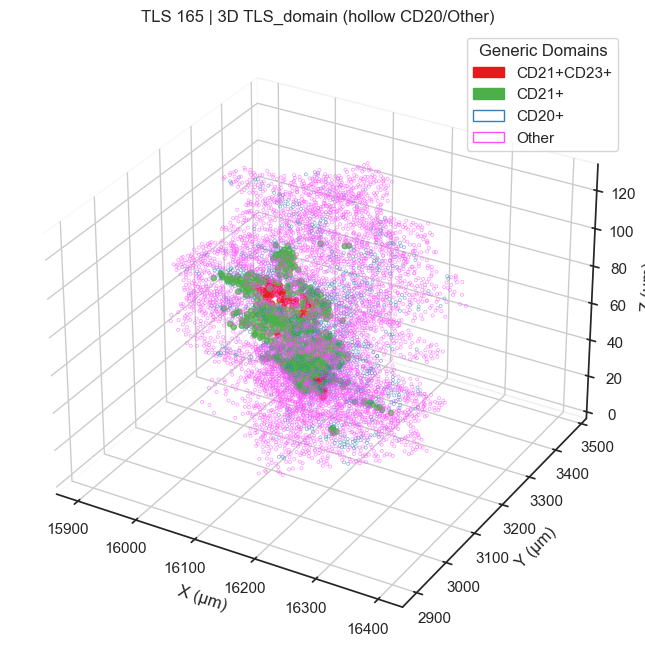

✅ Saved C:\Users\emo963\Downloads\figs\TLS165_TLS_domain_3D.pdf


In [251]:
# # === Run for all TLS ===

#[ early: 263, 597, 665, 766,    primary: 195, 430, 916,     
# # secondary:  260, 122, 216, 200, 165 (nice), 700 (nice]

# #plot_pdf = [260, 122, 216, 200, 165, 700, 403, 17, 29, 80 ]
# plot_pdf = [260, 122, 216, 200, 165, 700, 403, 17, 29, 80 ]
# # # Example: run for TLS 80
# for tls_id in plot_pdf:
    # export_tls_3d_fixed(adata, tls_id, domain_col="TLS_domain", outdir="figures/CD21_&_CD23_domain_zonations/TLS_domain_3D_MAIN")
export_tls_3d_fixed(adata, 165, domain_col="TLS_domain", outdir= r"C:\Users\emo963\Downloads\figs")

### Multifocal TLS Identification

In [257]:
## IDENTIFY MULTIFOCAL TLSs

import re
import pandas as pd

def detect_multifocal_tls(adata, domain_col="TLS_domain"):
    """
    Determine which TLSs are multifocal by detecting
    multiple CD21 or CD21_CD23 domain instances.

    Multifocal = more than one CD21_* OR more than one CD21_*_CD23_* domain.
    """

    tls_multifocal = {}

    # extract TLS number from domain string, e.g. TLS122_CD21_2 → 122
    def extract_tls_id(domain):
        if pd.isna(domain):
            return None
        m = re.match(r"TLS(\d+)_", str(domain))
        return int(m.group(1)) if m else None

    df = adata.obs[[domain_col]].copy()
    df["TLS"] = df[domain_col].apply(extract_tls_id)

    # group by TLS
    for tls_id, tls_df in df.groupby("TLS"):
        if tls_id is None:
            continue

        domains = tls_df[domain_col].dropna().unique().tolist()

        # ---- FIND CD21 DOMAINS ----
        cd21 = [d for d in domains if "_CD21_" in d and "_CD23_" not in d]

        # ---- FIND MERGED CD21–CD23 DOMAINS ----
        cd21_cd23 = [d for d in domains if "_CD21_" in d and "_CD23_" in d]

        # ---- MULTIFOCAL RULE ----
        multifocal = (len(cd21) > 1) or (len(cd21_cd23) > 1)

        tls_multifocal[tls_id] = {
            "TLS": tls_id,
            "n_CD21": len(cd21),
            "CD21_domains": cd21,
            "n_CD21_CD23": len(cd21_cd23),
            "CD21_CD23_domains": cd21_cd23,
            "is_multifocal": multifocal
        }

    return pd.DataFrame.from_dict(tls_multifocal, orient="index")

In [262]:
multifocal_df = detect_multifocal_tls(adata, domain_col="TLS_domain")
multifocal_df.to_csv('multifocal_TLS.csv')
multifocal_df.head()

,TLS,n_CD21,CD21_domains,n_CD21_CD23,CD21_CD23_domains,is_multifocal
17.0,17.0,1,[TLS17_CD21_1],2,"[TLS17_CD21_1_TLS17_CD23_2, TLS17_CD21_1_TLS17...",True
29.0,29.0,2,"[TLS29_CD21_1, TLS29_CD21_2]",2,"[TLS29_CD21_1_TLS29_CD23_1, TLS29_CD21_2_TLS29...",True
80.0,80.0,4,"[TLS80_CD21_1, TLS80_CD21_2, TLS80_CD21_3, TLS...",4,"[TLS80_CD21_1_TLS80_CD23_1, TLS80_CD21_2_TLS80...",True
105.0,105.0,1,[TLS105_CD21_1],1,[TLS105_CD21_1_TLS105_CD23_1],False
109.0,109.0,1,[TLS109_CD21_1],1,[TLS109_CD21_1_TLS109_CD23_1],False
